In [13]:
#dataset summary
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.describe(include='all')

Rows: 103024
Columns: 20


,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images
count,103024,103024,103024,103024,103024,103024,103024,103024,63967.000000,63967.000000,10499,18434,63967,3926,103024.000000,63967,103024.000000,63967.000000,63967.000000,103024
unique,NaN,1440,103024,4,94544,7,50,50,NaN,NaN,5,4,2,3,NaN,4,NaN,NaN,NaN,7
top,NaN,00:53:00,CNR7153255142,Success,CID954071,Prime Sedan,Banashankari,Peenya,NaN,NaN,Driver is not moving towards pickup location,Personal & Car related issue,No,Customer Demand,NaN,Cash,NaN,NaN,NaN,https://cdn-icons-png.flaticon.com/128/14183/1...
freq,NaN,101,1,63967,5,14877,2201,2159,NaN,NaN,3175,6542,60041,1601,NaN,35022,NaN,NaN,NaN,14877
mean,2024-07-16 11:31:38.879678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.876952,84.873372,NaN,NaN,NaN,NaN,548.751883,NaN,14.189927,3.997457,3.998313,NaN
min,2024-07-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.000000,25.000000,NaN,NaN,NaN,NaN,100.000000,NaN,0.000000,3.000000,3.000000,NaN
25%,2024-07-08 18:41:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.000000,55.000000,NaN,NaN,NaN,NaN,242.000000,NaN,0.000000,3.500000,3.500000,NaN
50%,2024-07-16 11:23:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,168.000000,85.000000,NaN,NaN,NaN,NaN,386.000000,NaN,8.000000,4.000000,4.000000,NaN
75%,2024-07-24 05:18:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,238.000000,115.000000,NaN,NaN,NaN,NaN,621.000000,NaN,26.000000,4.500000,4.500000,NaN
max,2024-07-31 23:58:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,308.000000,145.000000,NaN,NaN,NaN,NaN,2999.000000,NaN,49.000000,5.000000,5.000000,NaN


In [14]:
#missing values
missing = df.isnull().sum()
missing[missing > 0]

V_TAT                         39057
C_TAT                         39057
Canceled_Rides_by_Customer    92525
Canceled_Rides_by_Driver      84590
Incomplete_Rides              39057
Incomplete_Rides_Reason       99098
Payment_Method                39057
Driver_Ratings                39057
Customer_Rating               39057
dtype: int64

In [15]:
#Duplicate Records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


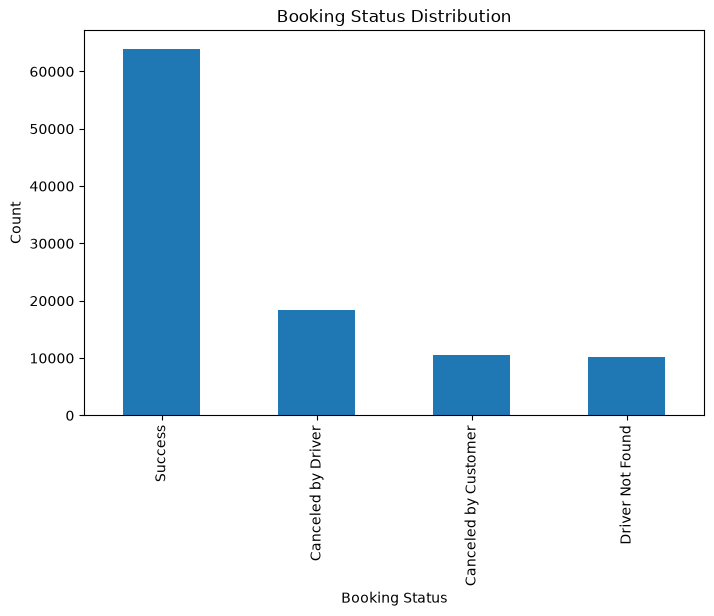

In [17]:
#Booking Status Distribution
import matplotlib.pyplot as plt

df['Booking_Status'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Booking Status Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Count")
plt.show()


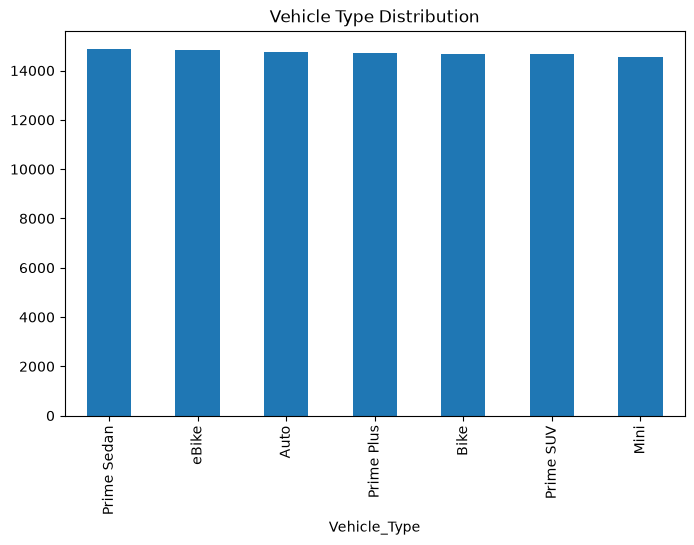

In [18]:
#Vehicle Type Distribution
df['Vehicle_Type'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Vehicle Type Distribution")
plt.show()

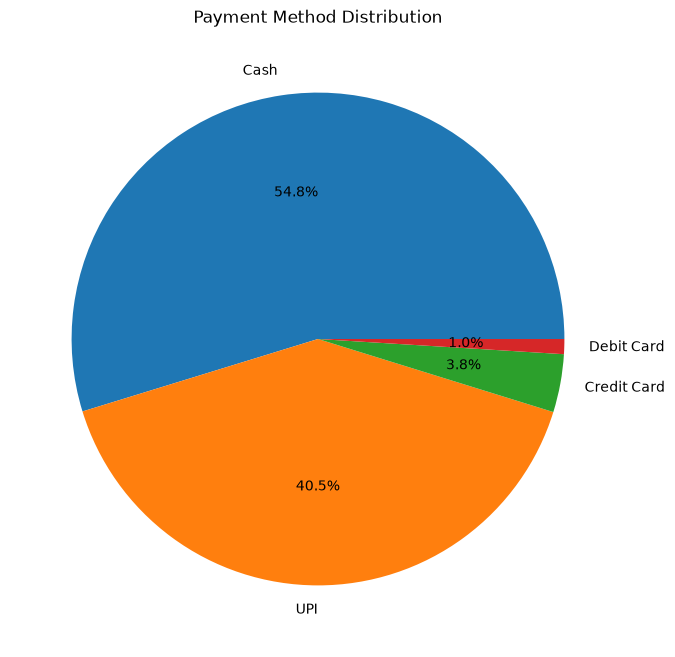

In [19]:
#Payment Method Analysis
df['Payment_Method'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()

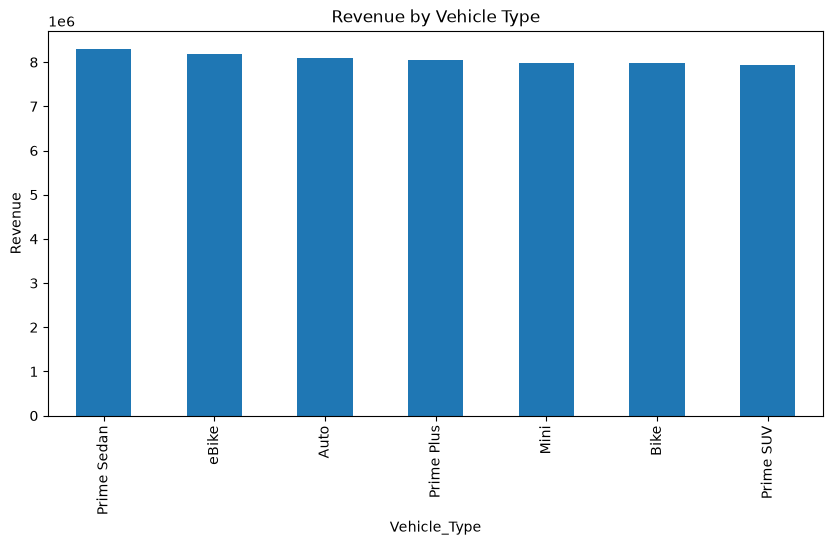

In [20]:
#Revenue by Vehicle Type
vehicle_revenue = df.groupby(
    'Vehicle_Type'
)['Booking_Value'].sum()

vehicle_revenue.sort_values(
    ascending=False
).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Revenue by Vehicle Type")
plt.ylabel("Revenue")
plt.show()

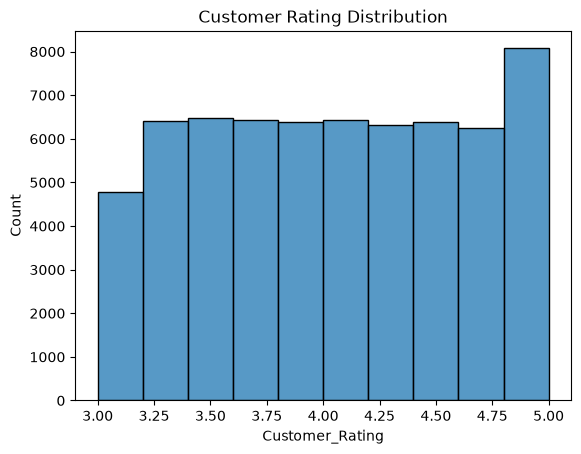

In [21]:
#Customer Ratings
import seaborn as sns

sns.histplot(
    df['Customer_Rating'].dropna(),
    bins=10
)

plt.title("Customer Rating Distribution")
plt.show()

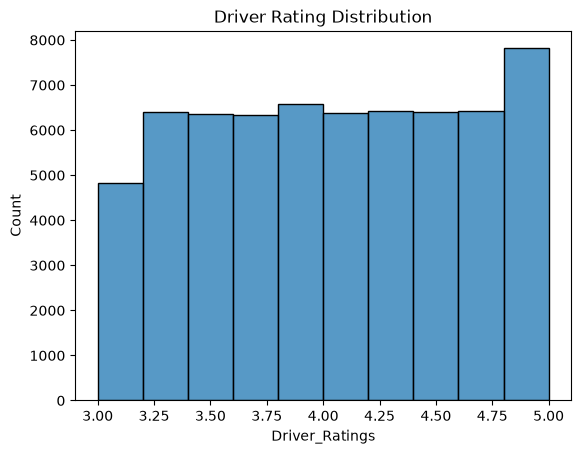

In [22]:
#Driver Ratings
sns.histplot(
    df['Driver_Ratings'].dropna(),
    bins=10
)

plt.title("Driver Rating Distribution")
plt.show()

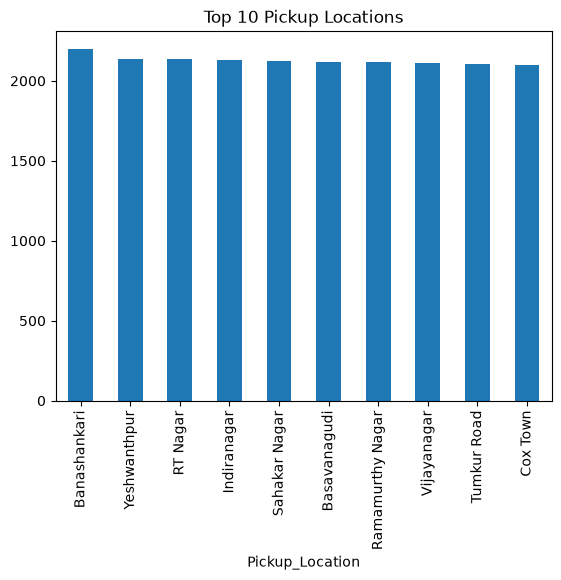

In [24]:
#Top Pickup Locations
df['Pickup_Location'].value_counts().head(10).plot(
    kind='bar'
)

plt.title("Top 10 Pickup Locations")
plt.show()

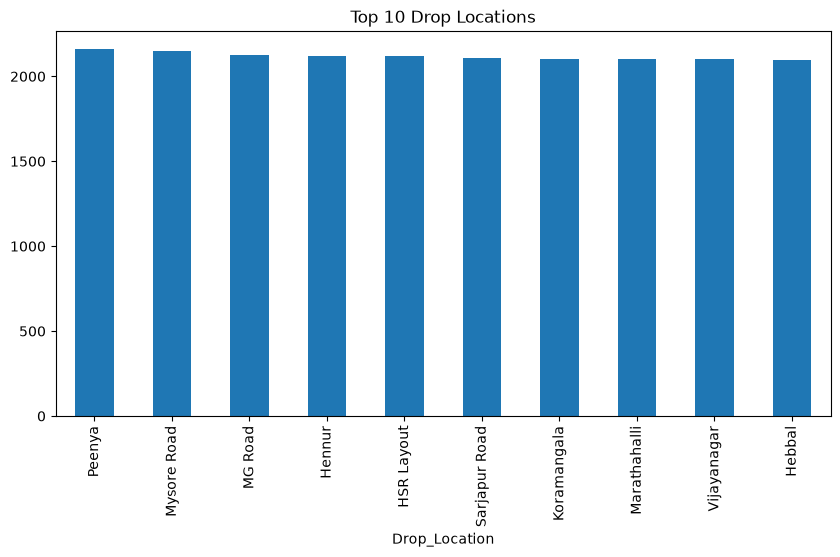

In [25]:
df['Drop_Location'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Drop Locations")
plt.show()

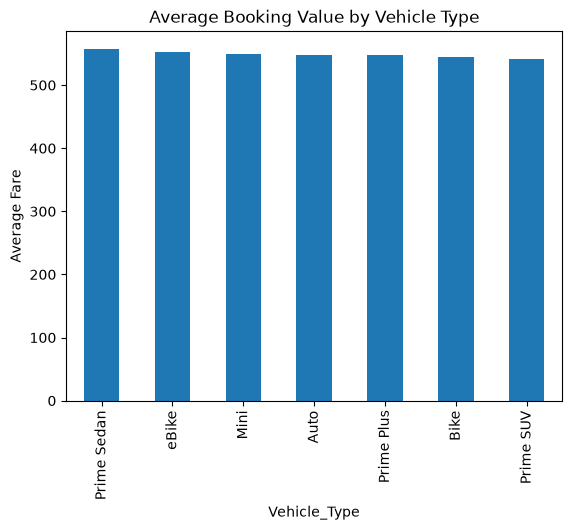

In [26]:
#Average Booking Value by Vehicle Type
df.groupby('Vehicle_Type')['Booking_Value']\
.mean()\
.sort_values(ascending=False)\
.plot(kind='bar')

plt.title("Average Booking Value by Vehicle Type")
plt.ylabel("Average Fare")
plt.show()

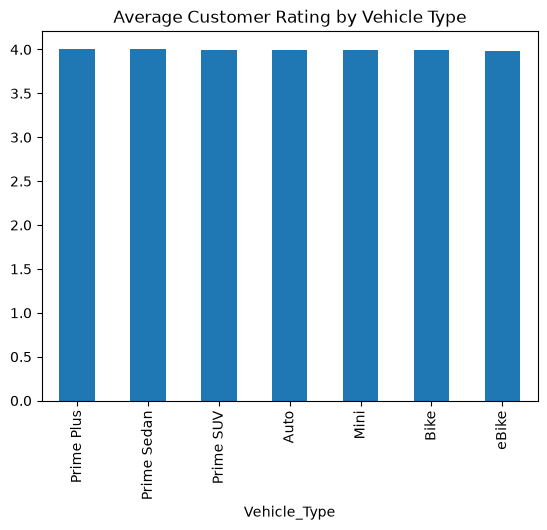

In [27]:
#Customer Rating by Vehicle Type
df.groupby('Vehicle_Type')['Customer_Rating']\
.mean()\
.sort_values(ascending=False)\
.plot(kind='bar')

plt.title("Average Customer Rating by Vehicle Type")
plt.show()

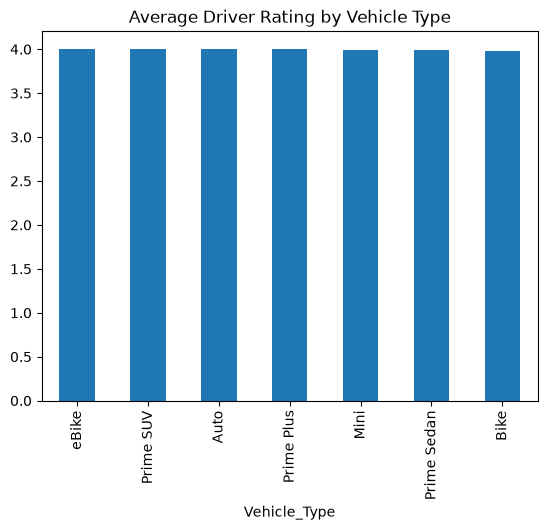

In [28]:
#Driver Rating by Vehicle Type
df.groupby('Vehicle_Type')['Driver_Ratings']\
.mean()\
.sort_values(ascending=False)\
.plot(kind='bar')

plt.title("Average Driver Rating by Vehicle Type")
plt.show()

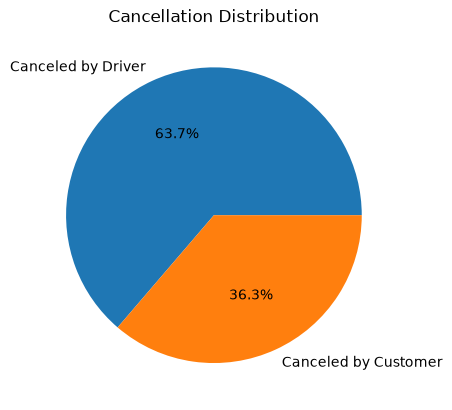

In [29]:
#Cancellation Analysis
cancelled = df[
    df['Booking_Status'].isin(
        ['Canceled by Customer',
         'Canceled by Driver']
    )
]

cancelled['Booking_Status']\
.value_counts()\
.plot(kind='pie', autopct='%1.1f%%')

plt.title("Cancellation Distribution")
plt.ylabel("")
plt.show()

In [30]:
import pandas as pd

df = pd.read_excel("OLA_DataSet.xlsx")

df.to_csv("ola_rides.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!
